In [21]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [22]:
x,y = make_regression(n_samples= 100, n_features=1, n_informative=1, n_targets=1, noise = 20, random_state=42)

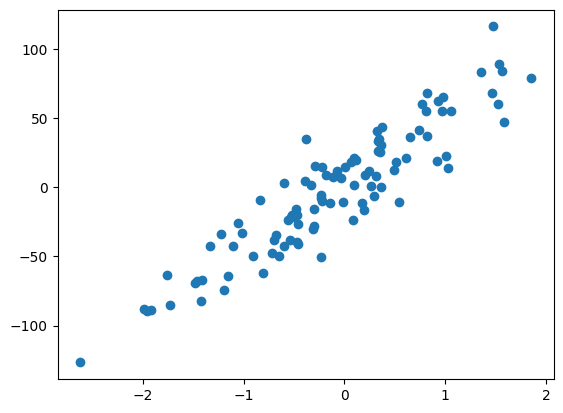

In [23]:
plt.scatter(x,y)

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
lr = LinearRegression()

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=2)

In [27]:
lr.fit(x_train, y_train)

LinearRegression()

In [28]:
y_pred = lr.predict(x_test)

In [29]:
from sklearn.metrics import r2_score

In [30]:
r2_score(y_test, y_pred)

0.878164919219213

In [31]:
print(lr.coef_)
print(lr.intercept_)

[46.56592693]
2.2713664531535667


In [32]:
from sklearn.linear_model import Ridge

In [33]:
rr = Ridge(alpha=10)
rr.fit(x_train, y_train)
print(rr.coef_)
print(rr.intercept_)

[40.50907887]
1.6920358576307177


In [34]:
rr2 = Ridge(alpha=100)
rr2.fit(x_train, y_train)
print(rr.coef_)
print(rr.intercept_)

[40.50907887]
1.6920358576307177


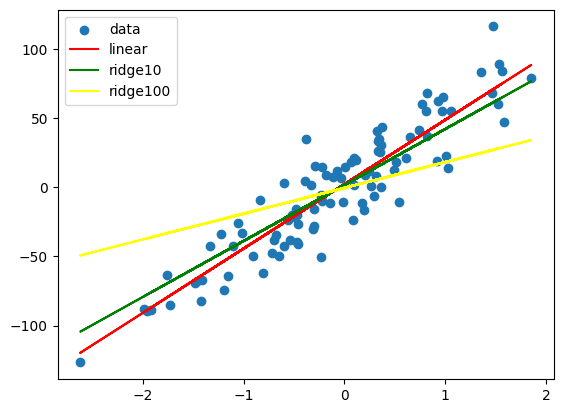

In [35]:
plt.scatter(x,y)
plt.plot(x, lr.predict(x), color = 'red')
plt.plot(x, rr.predict(x), color = 'green')
plt.plot(x, rr2.predict(x), color = 'yellow')
plt.legend(['data', 'linear', 'ridge10', 'ridge100'])

# Making Linear Ridge regression class

In [39]:
class myridge:
  def __init__(self, alpha = 0.1):
      self.alpha = alpha
      self.coef_ = None
      self.intercept_ = None

  def fit(self, x_train, y_train):
      num = 0
      den = 0

      for i in range(x_train.shape[0]):
        num = num + ((y_train[i] - y_train.mean()) * (x_train[i] - x_train.mean()))
        den = den + ((x_train[i] - x_train.mean()) * (x_train[i] - x_train.mean()))

      #updating the coeff

      self.coef_ = num/(den+self.alpha)
      self.intercept_ = y_train.mean() - (self.coef_ * x_train.mean())
      print(self.intercept_, self.coef_)

  def predict(self, x_test):
      return self.intercept_ + self.coef_ * x_test



In [40]:
rrmy = myridge(alpha=10)

In [41]:
rrmy.fit(x_train, y_train)

[1.69203586] [40.50907887]
